<div style="background:linear-gradient(135deg,#431407 0%,#c2410c 55%,#fb923c 100%);border-radius:18px;padding:30px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ffedd5;font-weight:700;text-transform:uppercase">Chapter 97 · Solutions</div>
  <div style="font-size:30px;font-weight:900;line-height:1.1;margin:10px 0 6px">Chapter 97 &#183; Solutions</div>
  <div style="font-size:14px;color:#fff7ed;max-width:740px;line-height:1.6">Five challenges, each verified in code.</div>

</div>

Solutions to the five challenges from Chapter 97, with scikit-learn pipelines and cross-validation.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, regplots, pairplots)
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
ORG="#ea580c"; DEEP="#c2410c"; LIGHT="#fdba74"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import warnings; warnings.filterwarnings('ignore')

In [3]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import RidgeCV, LassoCV
try:
    crops = pd.read_excel('../../data/ch97_crops.xlsx', sheet_name='Plots')
except FileNotFoundError:
    crops = pd.read_excel(BASE + 'ch97_crops.xlsx', sheet_name='Plots')
y = crops['yield'].values

<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#c2410c;letter-spacing:1px">CHALLENGE 1</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Bias-variance curve</div>
<div style="color:#4a5578;margin-top:5px">train vs CV R2 by degree.</div>
</div>

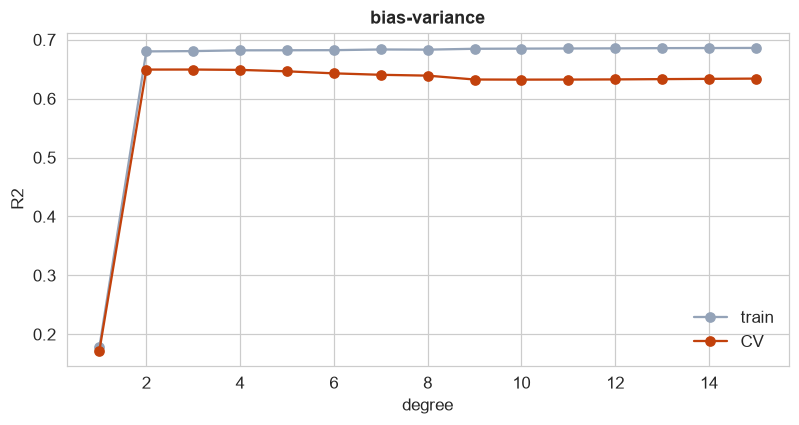

best degree = 3


In [4]:
xt = crops[['temperature']].values; degs=range(1,16); tr=[]; cv=[]
for d in degs:
    p = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    cv.append(cross_val_score(p, xt, y, cv=5, scoring='r2').mean()); tr.append(p.fit(xt,y).score(xt,y))
fig,ax=plt.subplots(figsize=(7.4,4)); ax.plot(list(degs),tr,'o-',color=GREY,label='train'); ax.plot(list(degs),cv,'o-',color=DEEP,label='CV')
ax.set(xlabel='degree',ylabel='R2',title='bias-variance'); ax.legend(); plt.tight_layout(); plt.show()
print('best degree =', list(degs)[int(np.argmax(cv))])

<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#c2410c;letter-spacing:1px">CHALLENGE 2</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Ridge vs OLS on correlated features</div>
<div style="color:#4a5578;margin-top:5px">fertilizer / soil coefficients.</div>
</div>

In [5]:
feats=['temperature','rainfall','fertilizer','soil_quality']
Xs=StandardScaler().fit_transform(crops[feats])
ols=LinearRegression().fit(Xs,y); ridge=RidgeCV(alphas=np.logspace(-2,3,50)).fit(Xs,y)
print(pd.DataFrame({'OLS':ols.coef_,'Ridge':ridge.coef_}, index=feats).round(3))

                OLS  Ridge
temperature   4.277  4.126
rainfall      1.803  1.744
fertilizer    1.818  1.788
soil_quality  2.500  2.424


<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#c2410c;letter-spacing:1px">CHALLENGE 3</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Lasso feature selection</div>
<div style="color:#4a5578;margin-top:5px">which features survive.</div>
</div>

In [6]:
crops['temp_sq']=(crops['temperature']-24)**2
feats=['temperature','temp_sq','rainfall','fertilizer','soil_quality','noise1','noise2','noise3']
Xs=StandardScaler().fit_transform(crops[feats]); lasso=LassoCV(cv=5,random_state=0).fit(Xs,y)
print('kept :', [f for f,c in zip(feats,lasso.coef_) if abs(c)>1e-6])
print('zeroed:', [f for f,c in zip(feats,lasso.coef_) if abs(c)<1e-6])

kept : ['temp_sq', 'rainfall', 'fertilizer', 'soil_quality', 'noise2']
zeroed: ['temperature', 'noise1', 'noise3']


<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#c2410c;letter-spacing:1px">CHALLENGE 4</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Cross-validate the penalty</div>
<div style="color:#4a5578;margin-top:5px">alpha and CV R2 for ridge and lasso.</div>
</div>

In [7]:
ridge=RidgeCV(alphas=np.logspace(-2,3,50)).fit(Xs,y)
print(f'RidgeCV alpha={ridge.alpha_:.3f}  CV R2={cross_val_score(ridge,Xs,y,cv=5,scoring="r2").mean():.3f}')
print(f'LassoCV alpha={lasso.alpha_:.3f}  CV R2={cross_val_score(lasso,Xs,y,cv=5,scoring="r2").mean():.3f}')

RidgeCV alpha=0.543  CV R2=0.896
LassoCV alpha=0.143  CV R2=0.898


<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#c2410c;letter-spacing:1px">CHALLENGE 5</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Polynomial vs spline</div>
<div style="color:#4a5578;margin-top:5px">compare CV fit on temperature.</div>
</div>

In [8]:
from sklearn.preprocessing import SplineTransformer
xt=crops[['temperature']].values
poly=make_pipeline(PolynomialFeatures(2),StandardScaler(),LinearRegression())
spl =make_pipeline(SplineTransformer(n_knots=5,degree=3),LinearRegression())
print(f'poly deg2 CV R2 = {cross_val_score(poly,xt,y,cv=5,scoring="r2").mean():.3f}')
print(f'cubic spline CV R2 = {cross_val_score(spl,xt,y,cv=5,scoring="r2").mean():.3f}')

poly deg2 CV R2 = 0.649
cubic spline CV R2 = 0.645


---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>